# MC62 — Eddy Current Settling Analysis — `04_staircase_2Hz_morning`

**Magnet**: MC62 (red bulk C-shaped dipole)  
**Machine**: LEAR antiproton decelerator, CERN  
**Test**: `04_staircase_2Hz_morning` — streaming measurement (2026-02-17)  
**Rotation**: 2 Hz (120 rpm), 512 samples/turn, ~0.5 s per turn  
**Current cycle**: precycles + staircase 0→+200→0→−200→0 A in 20 A steps (1 A/s ramp rate)  
**Settling**: ~800 turns per plateau at 2 Hz = ~400 s per step  

---

This notebook studies eddy-current settling transients in B1, b2, and b3
at each staircase plateau. At 2 Hz rotation, one turn = 0.5 s, giving
excellent time resolution for fitting exponential decay constants.

**Reproducibility check**: This is a repeat of `03_staircase_2Hz` (2026-02-16)
taken the following morning, to verify measurement reproducibility.

## Physical Background — Eddy Currents in Iron-Dominated Magnets

When the excitation current steps between staircase levels, the sudden $\Delta I$ induces **eddy currents** in the iron yoke and laminated core. These eddy currents produce a transient magnetic field that decays exponentially as the currents dissipate through resistive heating.

### Physical time constant

For a conducting slab of thickness $d$, the fundamental eddy-current time constant is (Bottura, *"Magnet Design"*):

$$
\tau = \frac{\mu_0 \, \mu_r \, \sigma \, d^2}{\pi^2}
$$

where $\mu_r$ is the relative permeability, $\sigma$ the iron conductivity, and $d$ the lamination thickness. Since $\mu_r$ depends on the magnetisation state:

- **Low current** ($|I| \lesssim 100$ A): high $\mu_r$ → large $\tau$ → slow settling
- **Saturation** ($|I| \gtrsim 180$ A): $\mu_r$ drops → small $\tau$ → fast settling

This current-dependent $\tau(\mu_r)$ is a key observable: it directly probes the iron permeability at each operating point.

### Impact on measurements

If the plateau average includes turns where eddy currents have not yet settled, the result carries a systematic **eddy-current bias**. This notebook quantifies the bias and determines the minimum number of turns to skip (`N_LAST_TURNS`) to ensure negligible contamination.


## 1. Configuration

In [1]:
from pathlib import Path
import numpy as np

# ── Paths ──────────────────────────────────────────────────────────────────
MEAS_DIR = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer"
                r"\measurements\MC62\2026-02-17_staircase_2Hz_morning\aperture1")

BIN_INTEGRAL = MEAS_DIR / "MC62_20260217_094521_staircase_2Hz_corr_sigs_Ap_1_SegIntegral.bin"

# Kn files -- external calibration (same PCBs as previous MC62 tests)
KN_DIR      = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer"
                   r"\measurements\MC62\2026-02-11\Kn values")
KN_INTEGRAL = KN_DIR / "Kn_R45_PCB_N1_0001_A_AC.txt"       # 30 harmonics

# ── Magnet & coil parameters ──────────────────────────────────────────────
MAGNET_ORDER     = 1        # dipole
R_REF            = 0.033    # reference radius [m]
SAMPLES_PER_TURN = 512      # encoder samples per revolution
RPM              = 120      # rotation speed
T_PER_TURN       = 60.0 / RPM  # 0.5 s per turn

# ── Pipeline options ──────────────────────────────────────────────────
OPTIONS    = ("dri", "rot", "cel", "fed")
DRIFT_MODE = "legacy"
MIN_B1_T   = 1e-6

# ── Sign convention ───────────────────────────────────────────────────
FLIP_SIGNAL_POLARITY = False    # True = negate all harmonics (inverted coil/cable polarity)
ENCODER_OFFSET_RAD = np.pi    # 180-deg encoder offset (MC62 2024 vs 2022 convention)

# ── Settling analysis parameters ─────────────────────────────────────
N_SETTLED        = 100       # last N turns used as "settled" reference
N_SHOW_SETTLING  = 400       # turns to show in settling plots
MIN_I_FOR_FIT    = 10.0      # minimum |I_nom| for exponential fit [A]

# ── Plateau detection ─────────────────────────────────────────────────
PLATEAU_I_RANGE_MAX = 0.5    # plateau detection threshold
PLATEAU_MIN_LENGTH  = 50     # min turns per group
PLATEAU_MERGE_GAP   = 100    # merge consecutive groups at same I_nom if gap < this

print(f"MC62 Eddy Current Analysis -- staircase_2Hz_morning")
print(f"  Rotation: {RPM} rpm -> {T_PER_TURN:.2f} s/turn")
print(f"  Settled reference: last {N_SETTLED} turns ({N_SETTLED*T_PER_TURN:.0f} s)")
print(f"  Sign convention: {'Tesla columns sign-flipped' if FLIP_SIGNAL_POLARITY else 'raw'}")
print(f"  Encoder offset:   {ENCODER_OFFSET_RAD:.4f} rad ({np.degrees(ENCODER_OFFSET_RAD):.1f} deg)")
print(f"  Plateau threshold: {PLATEAU_I_RANGE_MAX} A, min_length={PLATEAU_MIN_LENGTH}")

MC62 Eddy Current Analysis -- staircase_2Hz_morning
  Rotation: 120 rpm -> 0.50 s/turn
  Settled reference: last 100 turns (50 s)
  Sign convention: raw
  Plateau threshold: 0.5 A, min_length=50


## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

%matplotlib widget

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
})

from rotating_coil_analyzer.analysis.kn_pipeline import load_segment_kn_txt
from rotating_coil_analyzer.analysis.utility_functions import (
    EddyFitResult,
    FdiTransitionCheck,
    compute_block_averaged_range,
    detect_plateau_turns,
    diagnose_fdi_transitions,
    eddy_model,
    find_contiguous_groups,
    fit_eddy_per_run,
    process_kn_pipeline,
    build_harmonic_rows,
    diagnose_cel_fed,
)
from rotating_coil_analyzer.ingest.channel_detect import robust_range

print("Imports ready.")

Imports ready.


## 3. Load Data & Identify Staircase Plateaus

In [3]:
kn_integral = load_segment_kn_txt(str(KN_INTEGRAL))
print(f"Kn loaded: {len(kn_integral.orders)} harmonics")

# Load binary data
Ns = SAMPLES_PER_TURN
N_COLS = 4
raw = np.fromfile(str(BIN_INTEGRAL), dtype="<f8")
n_samples = len(raw) // N_COLS
n_turns = n_samples // Ns
n_keep = n_turns * Ns
raw = raw[:n_keep * N_COLS].reshape(n_keep, N_COLS)

t_all   = raw[:, 0].reshape(n_turns, Ns)
ch1_all = raw[:, 1].reshape(n_turns, Ns)
ch2_all = raw[:, 2].reshape(n_turns, Ns)
I_all   = raw[:, 3].reshape(n_turns, Ns)

# Channel detection
I_mean_quick = I_all.mean(axis=1)
best_turn = np.argmax(np.abs(I_mean_quick))
rr1 = robust_range(ch1_all[best_turn])
rr2 = robust_range(ch2_all[best_turn])
SWAP = rr2 > rr1
flux_abs = ch2_all if SWAP else ch1_all
flux_cmp = ch1_all if SWAP else ch2_all

print(f"Loaded: {n_turns} turns, time span: {t_all[0,0]:.1f}-{t_all[-1,-1]:.1f} s")
print(f"Channel detection: {'SWAP' if SWAP else 'no swap'}")

# Plateau detection
I_mean = I_all.mean(axis=1)
t_mean = t_all.mean(axis=1)
N_BLOCKS = 10
I_range, I_blocks = compute_block_averaged_range(I_all, Ns, N_BLOCKS)
plateau_info = detect_plateau_turns(I_blocks, I_mean, I_range, PLATEAU_I_RANGE_MAX)
is_plateau = plateau_info["is_plateau"]

# Identify plateau groups with merge step
plateau_groups_raw = find_contiguous_groups(is_plateau, min_length=PLATEAU_MIN_LENGTH)

group_info = []
for gi, (gs, ge) in enumerate(plateau_groups_raw):
    I_grp = I_mean[gs:ge+1]
    I_nom = round(I_grp.mean() / 20) * 20
    group_info.append({
        "group": gi, "start": gs, "end": ge,
        "n_turns": ge - gs + 1, "I_mean": I_grp.mean(), "I_nom": I_nom,
    })

# Merge consecutive groups at same I_nom with small gap
merged = [group_info[0].copy()]
for g in group_info[1:]:
    prev = merged[-1]
    gap = g["start"] - prev["end"]
    if g["I_nom"] == prev["I_nom"] and gap < PLATEAU_MERGE_GAP:
        prev["end"] = g["end"]
        prev["n_turns"] = prev["end"] - prev["start"] + 1
        I_slice = I_mean[prev["start"]:prev["end"]+1]
        prev["I_mean"] = I_slice.mean()
    else:
        merged.append(g.copy())

for i, g in enumerate(merged):
    g["group"] = i

# Identify staircase start (first long 0 A plateau)
staircase_start_group = None
for i, g in enumerate(merged):
    if abs(g["I_nom"]) < 2.0 and g["n_turns"] >= 500:
        staircase_start_group = i
        break

if staircase_start_group is None:
    staircase_start_group = 0
    staircase_start_turn = 0
    print("WARNING: could not identify staircase start, treating all data as staircase")
else:
    staircase_start_turn = merged[staircase_start_group]["start"]

# Build staircase run map
staircase_groups_list = [g for i, g in enumerate(merged) if i >= staircase_start_group]

run_info_list = []
for ri, g in enumerate(staircase_groups_list):
    run_info_list.append({
        "run_id": ri, "start": g["start"], "end": g["end"],
        "n_turns": g["n_turns"], "I_nom": g["I_nom"],
    })

# Branch direction
for i in range(len(run_info_list)):
    if i == 0:
        run_info_list[i]["branch"] = "ascending"
    elif run_info_list[i]["I_nom"] > run_info_list[i-1]["I_nom"]:
        run_info_list[i]["branch"] = "ascending"
    elif run_info_list[i]["I_nom"] < run_info_list[i-1]["I_nom"]:
        run_info_list[i]["branch"] = "descending"
    else:
        run_info_list[i]["branch"] = run_info_list[i-1]["branch"]

print(f"\nStaircase: {len(run_info_list)} plateaus (from turn {staircase_start_turn})")
for r in run_info_list:
    print(f"  Run {r['run_id']:02d}: I_nom={r['I_nom']:+4.0f} A, "
          f"{r['n_turns']:4d} turns, {r['branch']}")

Kn loaded: 30 harmonics
Loaded: 32544 turns, time span: 0.0-16447.0 s
Channel detection: no swap



Staircase: 21 plateaus (from turn 14600)
  Run 00: I_nom=  +0 A,  745 turns, ascending
  Run 01: I_nom= -20 A,  744 turns, descending
  Run 02: I_nom= -40 A,  743 turns, descending
  Run 03: I_nom= -60 A,  743 turns, descending
  Run 04: I_nom= -80 A,  745 turns, descending
  Run 05: I_nom=-100 A,  746 turns, descending
  Run 06: I_nom=-120 A,  744 turns, descending
  Run 07: I_nom=-140 A,  743 turns, descending
  Run 08: I_nom=-160 A,  745 turns, descending
  Run 09: I_nom=-180 A,  744 turns, descending
  Run 10: I_nom=-200 A,  746 turns, descending
  Run 11: I_nom=-180 A,  744 turns, ascending
  Run 12: I_nom=-160 A,  744 turns, ascending
  Run 13: I_nom=-140 A,  743 turns, ascending
  Run 14: I_nom=-120 A,  745 turns, ascending
  Run 15: I_nom=-100 A,  693 turns, ascending
  Run 16: I_nom= -80 A,  742 turns, ascending
  Run 17: I_nom= -60 A,  745 turns, ascending
  Run 18: I_nom= -40 A,  747 turns, ascending
  Run 19: I_nom= -20 A,  744 turns, ascending
  Run 20: I_nom=  +0 A, 2323

## cel/fed Safety Diagnostic

Run `diagnose_cel_fed()` to check whether the centre-location +
feeddown correction is safe for this data.

In [4]:
# Use a sample of turns for the diagnostic (e.g., first 100 turns)
_n_diag = min(100, flux_abs.shape[0])
diag = diagnose_cel_fed(
    flux_abs[:_n_diag], flux_cmp[:_n_diag],
    t_all[:_n_diag], I_all[:_n_diag],
    kn=kn_integral, r_ref=R_REF, magnet_order=MAGNET_ORDER,
)
print(f"cel/fed diagnostic: {diag.recommendation}")
print(f"  {diag.reason}")
_Bd = np.max(np.abs(diag.B_main_with_fed - diag.B_main_without_fed))
print(f"  B_main max |diff|: {_Bd:.4e} T")
del _n_diag, _Bd

# Act on diagnostic: disable cel/fed if unsafe
if diag.recommendation == "UNSAFE":
    OPTIONS = tuple(o for o in OPTIONS if o not in ("cel", "fed"))
    print(f"  -> cel/fed disabled, OPTIONS = {OPTIONS}")
else:
    print(f"  -> cel/fed safe, keeping OPTIONS = {OPTIONS}")


cel/fed diagnostic: UNSAFE
  100/100 turns (100%) have |zR| > 0.0100 (median 0.1051, max 0.1102). cel/fed produces unreliable offsets — skip it and use OPTIONS = ('dri', 'rot').
  B_main max |diff|: 3.6777e-06 T
  -> cel/fed disabled, OPTIONS = ('dri', 'rot')


## FDI Stuck-Channel Diagnostic

Check whether the Fast Digital Integrator (FDI) responded correctly during
current ramps between consecutive plateaus.  A "stuck" FDI produces fake
settling transients that corrupt eddy-current fits.

In [5]:
# ── FDI stuck-channel diagnostic ──────────────────────────────────────
fdi_checks = diagnose_fdi_transitions(
    flux_abs, I_mean, run_info_list, n_boundary=10,
)

# Summary table
print(f"FDI transition diagnostic ({len(fdi_checks)} transitions checked):")
print(f"{'From':>5s} {'To':>5s} {'I_before':>9s} {'I_after':>9s} "
      f"{'ΔI':>6s} {'gap':>5s} {'rng_bef':>9s} {'rng_start':>9s} "
      f"{'rng_settl':>9s} {'resp_ratio':>10s} {'Status':>8s}")
print("-" * 105)
for c in fdi_checks:
    status_color = {"OK": "", "PARTIAL": "(*)", "STUCK": "<<<"}
    print(f"{c.run_before:5d} {c.run_after:5d} {c.I_before:+9.0f} {c.I_after:+9.0f} "
          f"{c.delta_I:+6.0f} {c.n_gap_turns:5d} {c.flux_rng_before:9.4e} "
          f"{c.flux_rng_after_start:9.4e} {c.flux_rng_after_settled:9.4e} "
          f"{c.response_ratio:10.3f} {c.severity:>8s} {status_color.get(c.severity, '')}")

# Identify stuck runs
fdi_stuck_run_ids = {c.run_after for c in fdi_checks if c.is_stuck}
fdi_partial_run_ids = {c.run_after for c in fdi_checks if c.severity == "PARTIAL"}

n_stuck = sum(1 for c in fdi_checks if c.is_stuck)
n_partial = sum(1 for c in fdi_checks if c.severity == "PARTIAL")
n_ok = sum(1 for c in fdi_checks if c.severity == "OK")

if n_stuck > 0:
    print(f"\n{'!'*60}")
    print(f"  WARNING: {n_stuck} STUCK FDI transition(s) detected!")
    print(f"  Affected runs (start of plateau): {sorted(fdi_stuck_run_ids)}")
    print(f"  These runs have corrupted B1 at the start of the plateau.")
    print(f"  Eddy-current fits for these runs will be flagged.")
    print(f"{'!'*60}")
elif n_partial > 0:
    print(f"\n  Note: {n_partial} PARTIAL response transition(s) detected.")
    print(f"  Affected runs: {sorted(fdi_partial_run_ids)}")
else:
    print(f"\n  All {n_ok} transitions OK — FDI responded normally.")

FDI transition diagnostic (20 transitions checked):
 From    To  I_before   I_after     ΔI   gap   rng_bef rng_start rng_settl resp_ratio   Status
---------------------------------------------------------------------------------------------------------
    0     1        +0       -20    -20    39 1.4060e-05 8.3991e-04 8.7979e-04      0.954       OK 
    1     2       -20       -40    -20    38 8.7979e-04 1.7282e-03 1.7718e-03      0.951       OK 
    2     3       -40       -60    -20    39 1.7718e-03 2.6143e-03 2.6622e-03      0.946       OK 
    3     4       -60       -80    -20    38 2.6622e-03 3.4931e-03 3.5539e-03      0.932       OK 
    4     5       -80      -100    -20    36 3.5539e-03 4.3682e-03 4.4431e-03      0.916       OK 
    5     6      -100      -120    -20    37 4.4431e-03 5.2558e-03 5.3220e-03      0.925       OK 
    6     7      -120      -140    -20    38 5.3220e-03 6.1118e-03 6.1630e-03      0.939       OK 
    7     8      -140      -160    -20    37 6.1630e-0

## 4. Process All Staircase Turns Through Kn Pipeline

In [6]:
all_rows = []

for ri_info in run_info_list:
    gs = ri_info["start"]
    ge = ri_info["end"]
    idx = np.arange(gs, ge + 1)
    n = len(idx)

    try:
        result, C_merged, C_units, ok_main = process_kn_pipeline(
            flux_abs_turns=flux_abs[idx],
            flux_cmp_turns=flux_cmp[idx],
            t_turns=t_all[idx],
            I_turns=I_all[idx],
            kn=kn_integral,
            r_ref=R_REF,
            magnet_order=MAGNET_ORDER,
            options=OPTIONS,
            drift_mode=DRIFT_MODE,
            min_b1_T=MIN_B1_T,
            flip_signal_polarity=FLIP_SIGNAL_POLARITY,
            encoder_offset_rad=ENCODER_OFFSET_RAD,
            merge_mode="abs_upto_m_cmp_above",
        )

        extra = [{"run_id": ri_info["run_id"],
                  "I_nom": ri_info["I_nom"],
                  "branch": ri_info["branch"],
                  "turn_in_run": t}
                 for t in range(n)]
        rows = build_harmonic_rows(result, C_merged, C_units, ok_main,
                                   MAGNET_ORDER, extra)
        all_rows.extend(rows)
        n_ok = int(sum(ok_main))
        print(f"  Run {ri_info['run_id']:02d} "
              f"({ri_info['I_nom']:+4.0f} A, {ri_info['branch']:>10s}): "
              f"{n} turns, {n_ok} ok")
    except Exception as e:
        print(f"  Run {ri_info['run_id']:02d} ({ri_info['I_nom']:+4.0f} A): FAILED - {e}")

df = pd.DataFrame(all_rows)

print(f"\nTotal: {len(df)} turn-level rows across "
      f"{df['run_id'].nunique()} runs")

  Run 00 (  +0 A,  ascending): 745 turns, 745 ok
  Run 01 ( -20 A, descending): 744 turns, 744 ok
  Run 02 ( -40 A, descending): 743 turns, 743 ok
  Run 03 ( -60 A, descending): 743 turns, 743 ok


  Run 04 ( -80 A, descending): 745 turns, 745 ok


  Run 05 (-100 A, descending): 746 turns, 746 ok
  Run 06 (-120 A, descending): 744 turns, 744 ok
  Run 07 (-140 A, descending): 743 turns, 743 ok


  Run 08 (-160 A, descending): 745 turns, 745 ok
  Run 09 (-180 A, descending): 744 turns, 744 ok
  Run 10 (-200 A, descending): 746 turns, 746 ok


  Run 11 (-180 A,  ascending): 744 turns, 744 ok
  Run 12 (-160 A,  ascending): 744 turns, 744 ok
  Run 13 (-140 A,  ascending): 743 turns, 743 ok
  Run 14 (-120 A,  ascending): 745 turns, 745 ok
  Run 15 (-100 A,  ascending): 693 turns, 693 ok


  Run 16 ( -80 A,  ascending): 742 turns, 742 ok
  Run 17 ( -60 A,  ascending): 745 turns, 745 ok
  Run 18 ( -40 A,  ascending): 747 turns, 747 ok
  Run 19 ( -20 A,  ascending): 744 turns, 744 ok


  Run 20 (  +0 A,  ascending): 2323 turns, 2323 ok

Total: 17158 turn-level rows across 21 runs


## 5. Raw Settling Curves — B1 vs Turn Number

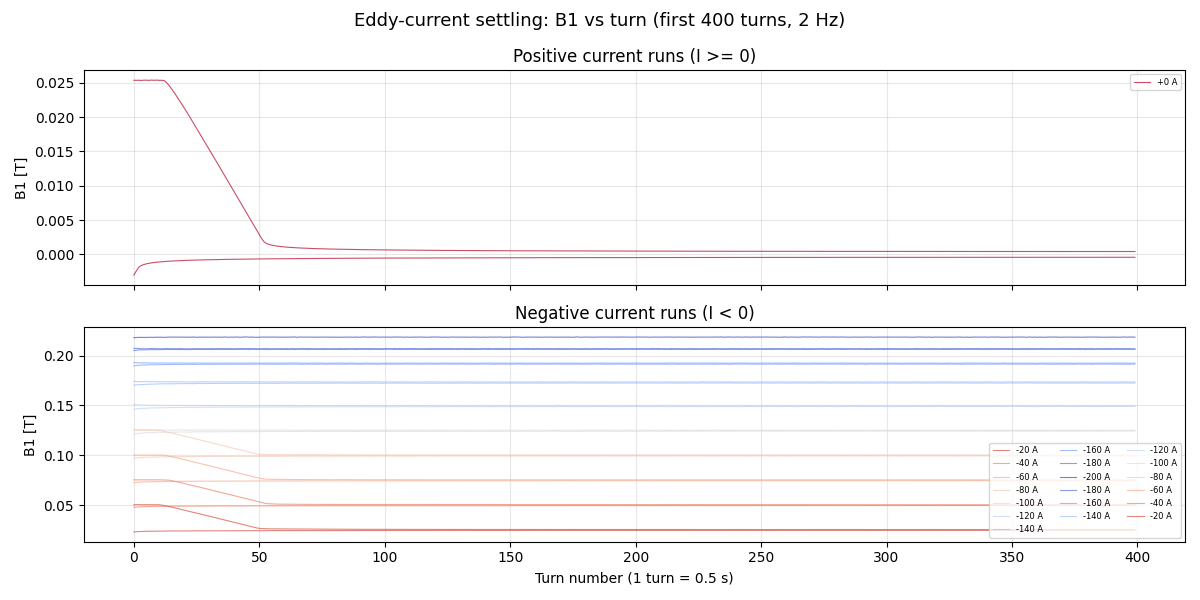

In [7]:
cmap = plt.cm.coolwarm
I_all_noms = sorted(df["I_nom"].unique())
norm_c = plt.Normalize(min(I_all_noms), max(I_all_noms))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Panel 1: positive current runs
ax = axes[0]
for run_id in sorted(df["run_id"].unique()):
    rdf = df[(df["run_id"] == run_id) & df["ok_main"]].sort_values("turn_in_run")
    if rdf.empty:
        continue
    I_nom = rdf["I_nom"].iloc[0]
    if I_nom < 0:
        continue
    first = rdf[rdf["turn_in_run"] < N_SHOW_SETTLING]
    if first.empty:
        continue
    color = cmap(norm_c(I_nom))
    ax.plot(first["turn_in_run"], first["B1_T"],
            "-", lw=0.8, color=color, alpha=0.7,
            label=f"{I_nom:+.0f} A" if run_id <= 10 else None)

ax.set_ylabel("B1 [T]")
ax.set_title("Positive current runs (I >= 0)")
ax.legend(fontsize=6, ncol=3, loc="upper right")

# Panel 2: negative current runs
ax = axes[1]
for run_id in sorted(df["run_id"].unique()):
    rdf = df[(df["run_id"] == run_id) & df["ok_main"]].sort_values("turn_in_run")
    if rdf.empty:
        continue
    I_nom = rdf["I_nom"].iloc[0]
    if I_nom >= 0:
        continue
    first = rdf[rdf["turn_in_run"] < N_SHOW_SETTLING]
    if first.empty:
        continue
    color = cmap(norm_c(I_nom))
    ax.plot(first["turn_in_run"], first["B1_T"],
            "-", lw=0.8, color=color, alpha=0.7,
            label=f"{I_nom:+.0f} A" if I_nom >= -200 and I_nom <= -20 else None)

ax.set_xlabel(f"Turn number (1 turn = {T_PER_TURN:.1f} s)")
ax.set_ylabel("B1 [T]")
ax.set_title("Negative current runs (I < 0)")
ax.legend(fontsize=6, ncol=3, loc="lower right")

fig.suptitle(f"Eddy-current settling: B1 vs turn (first {N_SHOW_SETTLING} turns, 2 Hz)",
             fontsize=13)
fig.tight_layout()
plt.show()

## 6. Exponential Fit Methodology

### Single-exponential model

After a current step, the main field settles according to:

$$
B_1(t) = B_\infty + A \cdot e^{-t/\tau}
$$

where:
- $B_\infty$ is the **asymptotic (settled) field** — the physical quantity we want to measure
- $A$ is the **eddy-current amplitude** ($A > 0$ for decaying overshoot, $A < 0$ for rising approach)
- $\tau$ is the **time constant** in turns (multiply by $T_{\rm turn} = 0.5$ s for seconds at 2 Hz)
- $t$ is measured in turn number from the start of the plateau

### Two-pass robust fitting algorithm

1. **Ramp trimming**: Discard leading turns where $|I_k - I_{\rm settled}| > 0.5$ A (current still transitioning between steps)
2. **Stuck-field trimming**: If $|B_1[0] - B_\infty^{\rm est}| > 10 \sigma_{\rm noise}$ but field hasn't started moving ($|B_1[k] - B_1[0]| < 5 \sigma_{\rm noise}$), trim those stuck turns
3. **Pass 1**: Fit via `scipy.optimize.curve_fit` with initial guesses:
   - $B_\infty^{(0)} = \langle B_1 \rangle_{\rm last\;100\;turns}$
   - $A^{(0)} = B_1[0] - B_\infty^{(0)}$
   - $\tau^{(0)} = 20$ turns
   - Bounds: $\tau \in [0.5, 1000]$ turns
4. **MAD outlier rejection** on residuals: $r_k = B_{1,k} - B_1^{\rm fit}(t_k)$
   $$\sigma_{\rm MAD} = 1.4826 \cdot \text{median}\left(|r_k - \tilde{r}|\right), \qquad \text{keep if } |r_k| < 5\,\sigma_{\rm MAD}$$
5. **Pass 2**: Refit on cleaned data, extract $\tau \pm \sigma_\tau$ from covariance

### Goodness of fit

$$
R^2 = 1 - \frac{\sum_k \left(B_{1,k} - B_1^{\rm fit}(t_k)\right)^2}{\sum_k \left(B_{1,k} - \bar{B}_1\right)^2}
$$

### Quality classification

| Category | Criterion | Physical meaning |
|:---------|:----------|:-----------------|
| **GOOD** | $R^2 \geq 0.9$ | Clear exponential transient, reliable $\tau$ |
| **MARGINAL** | $R^2 < 0.9$ | Small eddy amplitude relative to noise (expected at saturation) |
| **WEAK_SIGNAL** | $|A| < 3 \sigma_{\rm noise}$ | No detectable transient above noise floor |
| **FIT_FAILED** | Convergence failure | Insufficient data or pathological signal |


## 7. Fit Tau for Each Plateau

In [8]:
fit_results = []

for run_id in sorted(df["run_id"].unique()):
    rdf = df[(df["run_id"] == run_id) & df["ok_main"]].sort_values("turn_in_run")
    if rdf.empty:
        continue
    I_nom = rdf["I_nom"].iloc[0]
    branch = rdf["branch"].iloc[0]
    if abs(I_nom) < MIN_I_FOR_FIT:
        continue
    result = fit_eddy_per_run(
        rdf["turn_in_run"].values.astype(float),
        rdf["B1_T"].values,
        run_id=int(run_id), I_nom=I_nom, branch=branch,
        n_settled=N_SETTLED, tau_bounds=(0.5, 1000),
        I_mean=rdf["I_mean_A"].values,
    )
    fit_results.append(result)

df_fits_all = pd.DataFrame([vars(r) for r in fit_results])

# Flag FDI-stuck runs
df_fits_all["fdi_stuck"] = df_fits_all["run_id"].isin(fdi_stuck_run_ids)

# Print diagnostic table
print(f"Exponential fit results ({len(fit_results)} runs):")
print(f"{'Run':>4s} {'I [A]':>8s} {'Branch':>10s} {'tau [turns]':>11s} "
      f"{'tau [s]':>8s} {'A [T]':>12s} {'R²':>8s} {'n_out':>5s} {'n_trim':>6s} {'Quality':>12s} {'FDI':>4s} Reason")
print("-" * 135)
for r in fit_results:
    tau_s = r.tau * T_PER_TURN
    fdi_flag = " !!!" if r.run_id in fdi_stuck_run_ids else ""
    print(f"{r.run_id:4d} {r.I_nom:+8.1f} {r.branch:>10s} "
          f"{r.tau:11.1f} {tau_s:8.1f} {r.A:+12.6f} {r.r2:8.4f} {r.n_outliers:5d} "
          f"{r.n_trimmed:6d} {r.quality:>12s} {fdi_flag:>4s} {r.reason}")

# Separate good fits for tau-vs-I plots (exclude FDI-stuck runs)
df_fits = df_fits_all[(df_fits_all["quality"] == "GOOD") & ~df_fits_all["fdi_stuck"]].copy()
df_fits["abs_I"] = df_fits["I_nom"].abs()
df_fits["tau_s"] = df_fits["tau"] * T_PER_TURN
df_fits["tau_s_err"] = df_fits["tau_err"] * T_PER_TURN
n_fdi_excluded = df_fits_all["fdi_stuck"].sum()
print(f"\nGOOD fits: {len(df_fits)} / {len(df_fits_all)}"
      + (f" ({n_fdi_excluded} excluded due to FDI stuck)" if n_fdi_excluded > 0 else ""))
print(f"WEAK_SIGNAL: {(df_fits_all['quality'] == 'WEAK_SIGNAL').sum()}")
print(f"MARGINAL: {(df_fits_all['quality'] == 'MARGINAL').sum()}")
print(f"FIT_FAILED: {(df_fits_all['quality'] == 'FIT_FAILED').sum()}")

Exponential fit results (19 runs):
 Run    I [A]     Branch tau [turns]  tau [s]        A [T]       R² n_out n_trim      Quality  FDI Reason
---------------------------------------------------------------------------------------------------------------------------------------
   1    -20.0 descending        53.4     26.7    -0.000812   0.9610     5      0         GOOD      R2=0.9610
   2    -40.0 descending        54.1     27.0    -0.000955   0.9527     3      0         GOOD      R2=0.9527
   3    -60.0 descending        57.0     28.5    -0.001051   0.9415     3      0         GOOD      R2=0.9415
   4    -80.0 descending        54.0     27.0    -0.001241   0.9271     3      0         GOOD      R2=0.9271
   5   -100.0 descending        47.4     23.7    -0.001528   0.9237     3      1         GOOD      R2=0.9237
   6   -120.0 descending        42.7     21.4    -0.001643   0.9231     2      0         GOOD      R2=0.9231
   7   -140.0 descending        23.9     12.0    -0.001505   0.8582  

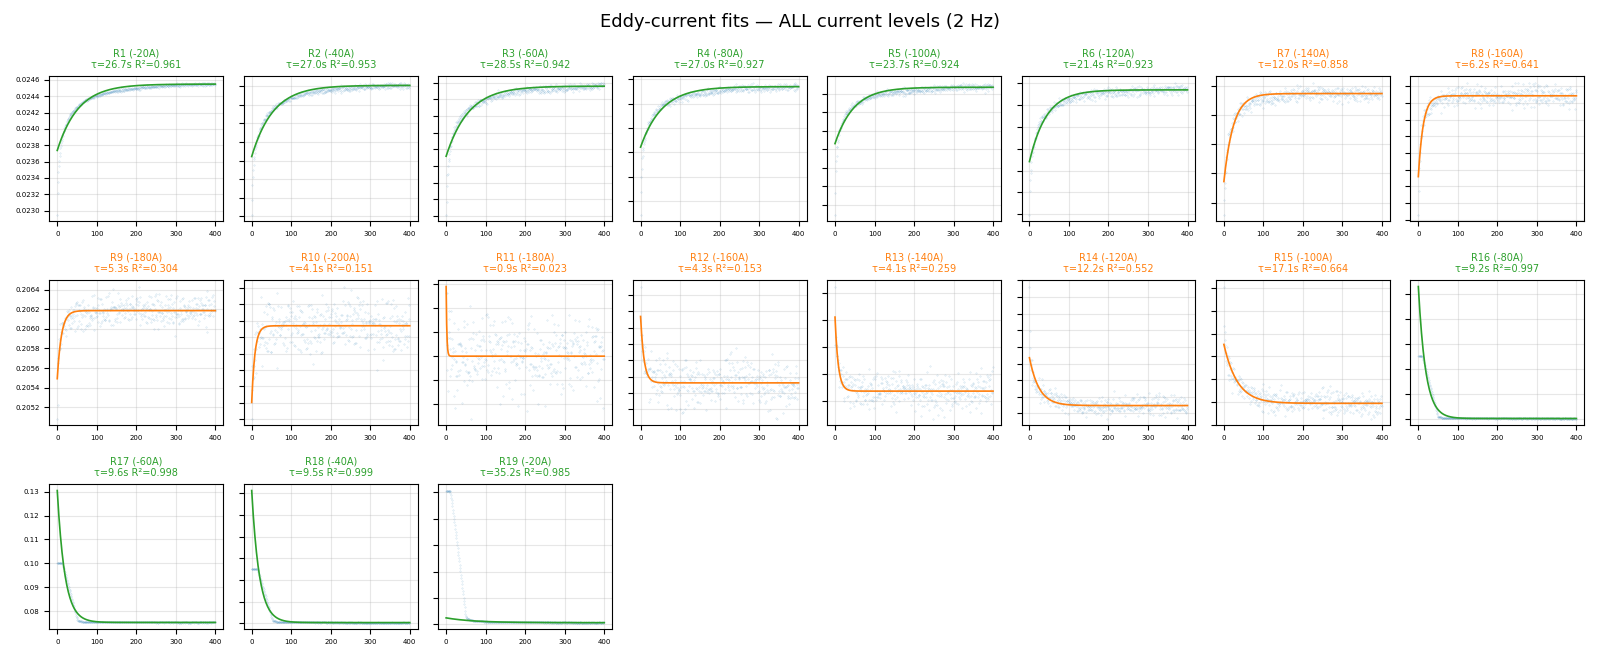

In [9]:
# Plot ALL fitted runs in a grid
n_runs = len(fit_results)
n_cols = 8
n_rows = (n_runs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2.2 * n_rows))
axes_flat = np.atleast_1d(axes).flatten()

quality_colors = {"GOOD": "tab:green", "MARGINAL": "tab:orange",
                  "WEAK_SIGNAL": "tab:gray", "FIT_FAILED": "tab:red"}

for idx, result in enumerate(fit_results):
    ax = axes_flat[idx]
    rdf = df[(df["run_id"] == result.run_id) & df["ok_main"]].sort_values("turn_in_run")
    turns = rdf["turn_in_run"].values.astype(float)
    B1 = rdf["B1_T"].values

    # Show first N_SHOW_SETTLING turns for clarity
    mask = turns < N_SHOW_SETTLING
    ax.plot(turns[mask], B1[mask], ".", ms=0.5, color="tab:blue", alpha=0.3)

    if np.isfinite(result.tau):
        t_fit = np.linspace(0, min(turns.max(), N_SHOW_SETTLING), 300)
        ax.plot(t_fit, eddy_model(t_fit, result.B_inf, result.A, result.tau),
                "-", lw=1.2, color=quality_colors.get(result.quality, "black"))

    tau_s = result.tau * T_PER_TURN
    ax.set_title(f"R{result.run_id} ({result.I_nom:+.0f}A)\n"
                 f"\u03c4={tau_s:.1f}s R\u00b2={result.r2:.3f}",
                 fontsize=7, color=quality_colors.get(result.quality, "black"))
    ax.tick_params(labelsize=5)
    if idx % n_cols != 0:
        ax.set_yticklabels([])

for idx in range(n_runs, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle("Eddy-current fits — ALL current levels (2 Hz)", fontsize=13)
fig.tight_layout()
plt.show()

## 8. Tau vs Current — The Permeability Effect

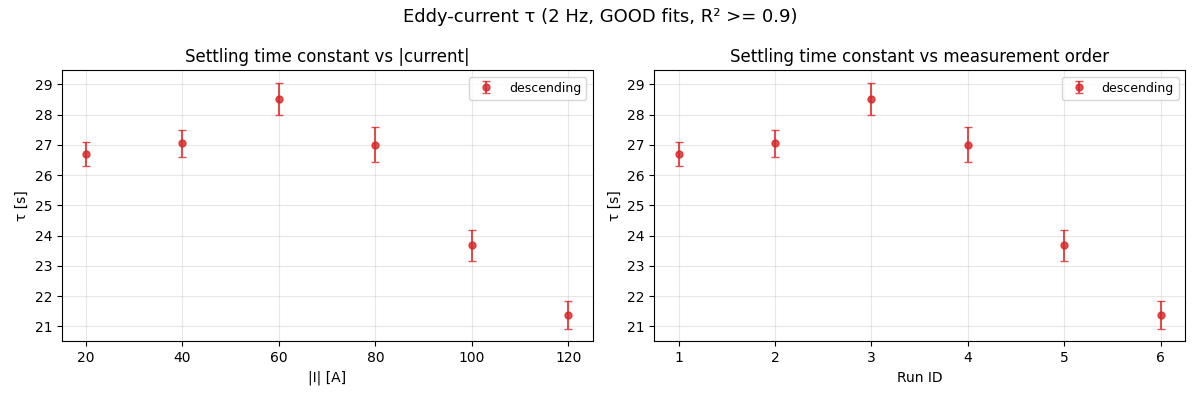


Tau statistics by |I| range (GOOD fits, 6 runs):
  |I| in [ 10,  60) A: τ = 26.9 ± 0.2 s (N=2, range 26.7–27.0 s)
  |I| in [ 60, 120) A: τ = 26.4 ± 2.5 s (N=3, range 23.7–28.5 s)
  |I| in [120, 180) A: τ = 21.4 ± nan s (N=1, range 21.4–21.4 s)


In [10]:
branch_colors = {"ascending": "tab:blue", "descending": "tab:red"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) tau (seconds) vs |I|
ax = axes[0]
for branch, col in branch_colors.items():
    mask = df_fits["branch"] == branch
    if mask.any():
        ax.errorbar(df_fits.loc[mask, "abs_I"], df_fits.loc[mask, "tau_s"],
                    yerr=df_fits.loc[mask, "tau_s_err"],
                    fmt="o", color=col, ms=5, capsize=3, alpha=0.8,
                    label=branch)
ax.set_xlabel("|I| [A]")
ax.set_ylabel("\u03c4 [s]")
ax.set_title("Settling time constant vs |current|")
ax.legend(fontsize=9)

# (b) tau vs run order
ax = axes[1]
for branch, col in branch_colors.items():
    mask = df_fits["branch"] == branch
    if mask.any():
        ax.errorbar(df_fits.loc[mask, "run_id"], df_fits.loc[mask, "tau_s"],
                    yerr=df_fits.loc[mask, "tau_s_err"],
                    fmt="o", color=col, ms=5, capsize=3, alpha=0.8,
                    label=branch)
ax.set_xlabel("Run ID")
ax.set_ylabel("\u03c4 [s]")
ax.set_title("Settling time constant vs measurement order")
ax.legend(fontsize=9)

fig.suptitle("Eddy-current \u03c4 (2 Hz, GOOD fits, R\u00b2 >= 0.9)", fontsize=13)
fig.tight_layout()
plt.show()

# Statistics by current range
print(f"\nTau statistics by |I| range (GOOD fits, {len(df_fits)} runs):")
for lo, hi in [(10, 60), (60, 120), (120, 180), (180, 210)]:
    mask = (df_fits["abs_I"] >= lo) & (df_fits["abs_I"] < hi)
    if mask.any():
        tau_s = df_fits.loc[mask, "tau_s"]
        print(f"  |I| in [{lo:3d}, {hi:3d}) A: "
              f"\u03c4 = {tau_s.mean():.1f} \u00b1 {tau_s.std():.1f} s "
              f"(N={mask.sum()}, range {tau_s.min():.1f}\u2013{tau_s.max():.1f} s)")

## 9. Impact on Harmonics — Settling Bias in b2, b3

The eddy-current transient affects not just $B_1$ but all harmonics. The **settling bias** quantifies how much a harmonic deviates from its settled value as a function of turn number.

### Bias definitions

**For $B_1$** (relative units, $10^{-4}$):

$$
\delta B_1(k) = 10^4 \cdot \frac{B_1(k) - \bar{B}_{1,\rm ref}}{|\bar{B}_{1,\rm ref}|}
$$

**For $b_n$, $a_n$** (absolute units):

$$
\delta b_n(k) = b_n(k) - \bar{b}_{n,\rm ref}
$$

where $\bar{(\cdot)}_{\rm ref}$ is the mean over the last $N_{\rm settled}$ turns (best estimate of $B_\infty$).

If $|\delta b_3| \ll 1$ unit for all turns included in the averaging window, the eddy-current transient does not bias the sextupole measurement.


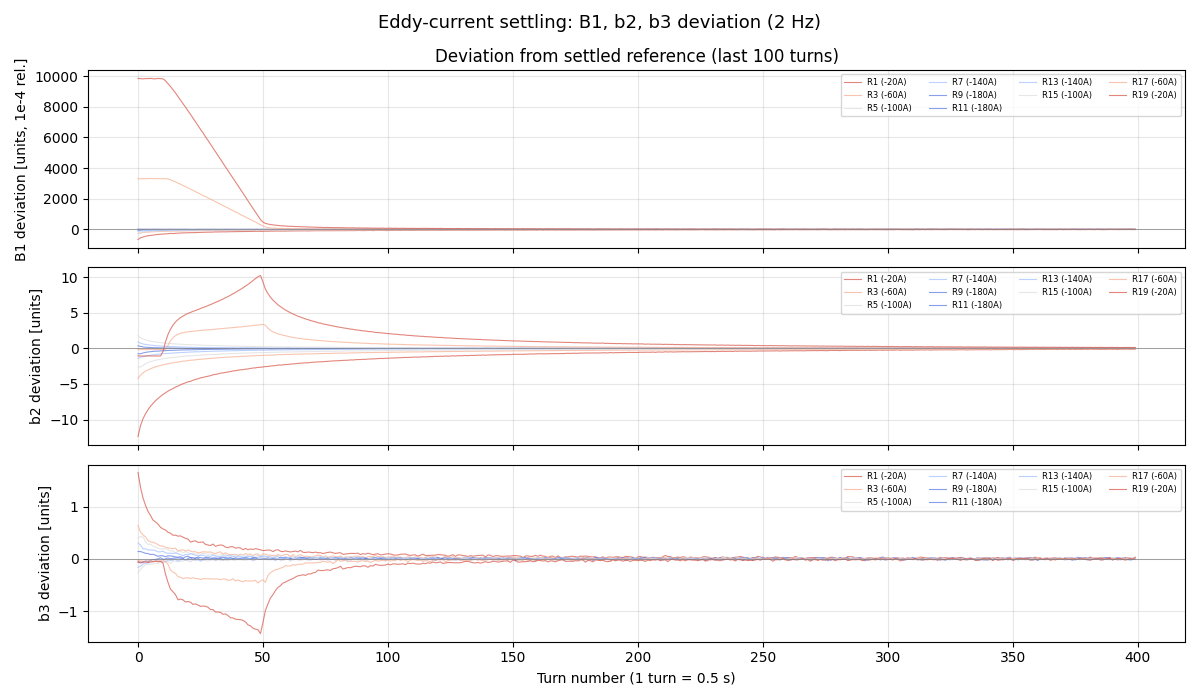

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

show_runs_dev = list(range(1, len(run_info_list), max(1, len(run_info_list)//8)))

for quantity, col_name, ax, ylabel in [
    ("B1", "B1_T", axes[0], "B1 deviation [units, 1e-4 rel.]"),
    ("b2", "b2_units", axes[1], "b2 deviation [units]"),
    ("b3", "b3_units", axes[2], "b3 deviation [units]"),
]:
    for run_id in show_runs_dev:
        rdf = df[(df["run_id"] == run_id) & df["ok_main"]].sort_values("turn_in_run")
        if rdf.empty or col_name not in rdf.columns:
            continue
        I_nom = rdf["I_nom"].iloc[0]
        if abs(I_nom) < MIN_I_FOR_FIT:
            continue

        vals = rdf[col_name].values
        turns = rdf["turn_in_run"].values

        ref = vals[-N_SETTLED:].mean()

        if quantity == "B1":
            if abs(ref) > 1e-10:
                dev = 1e4 * (vals - ref) / abs(ref)
            else:
                continue
        else:
            dev = vals - ref

        mask = turns < N_SHOW_SETTLING
        color = cmap(norm_c(I_nom))
        ax.plot(turns[mask], dev[mask], "-", lw=0.8, color=color, alpha=0.7,
                label=f"R{run_id} ({I_nom:+.0f}A)")

    ax.set_ylabel(ylabel)
    ax.axhline(0, color="gray", lw=0.5)
    ax.legend(fontsize=6, ncol=4, loc="upper right")

axes[0].set_title("Deviation from settled reference (last 100 turns)")
axes[-1].set_xlabel(f"Turn number (1 turn = {T_PER_TURN:.1f} s)")

fig.suptitle("Eddy-current settling: B1, b2, b3 deviation (2 Hz)", fontsize=13)
fig.tight_layout()
plt.show()

## 10. Sensitivity Study — N_LAST_TURNS

The number of turns averaged per plateau (`N_LAST_TURNS`) controls the trade-off between:
- **Statistical noise**: more turns → lower $\sigma / \sqrt{N}$
- **Eddy-current bias**: too many turns → includes early (unsettled) turns → systematic error

### Systematic bias definition

For a given $N_{\rm last}$, the systematic error on $B_1$ at plateau $r$ is:

$$
\epsilon_{B_1}(N_{\rm last}) = 10^4 \cdot \frac{\langle B_1 \rangle_{N_{\rm last}} - \langle B_1 \rangle_{\rm ref}}{|\langle B_1 \rangle_{\rm ref}|}
$$

where $\langle \cdot \rangle_{\rm ref}$ uses the last settled turns (best estimate of $B_\infty$). Similarly for $b_3$.

### Settling criterion

The theoretical safe window starts after $5\tau_{\rm max}$, where the transient has decayed to $e^{-5} \approx 0.7\%$ of its initial amplitude:

$$
N_{\rm safe} = N_{\rm turns/plateau} - \frac{5 \cdot \tau_{\rm max}}{T_{\rm turn}}
$$

For this test: $\tau_{\rm max} = 40$ s, $T_{\rm turn} = 0.5$ s → $5\tau_{\rm max} = 400$ turns → $N_{\rm safe} = 726 - 400 = 326$ (consistent with $N_{\rm last} = 340$).


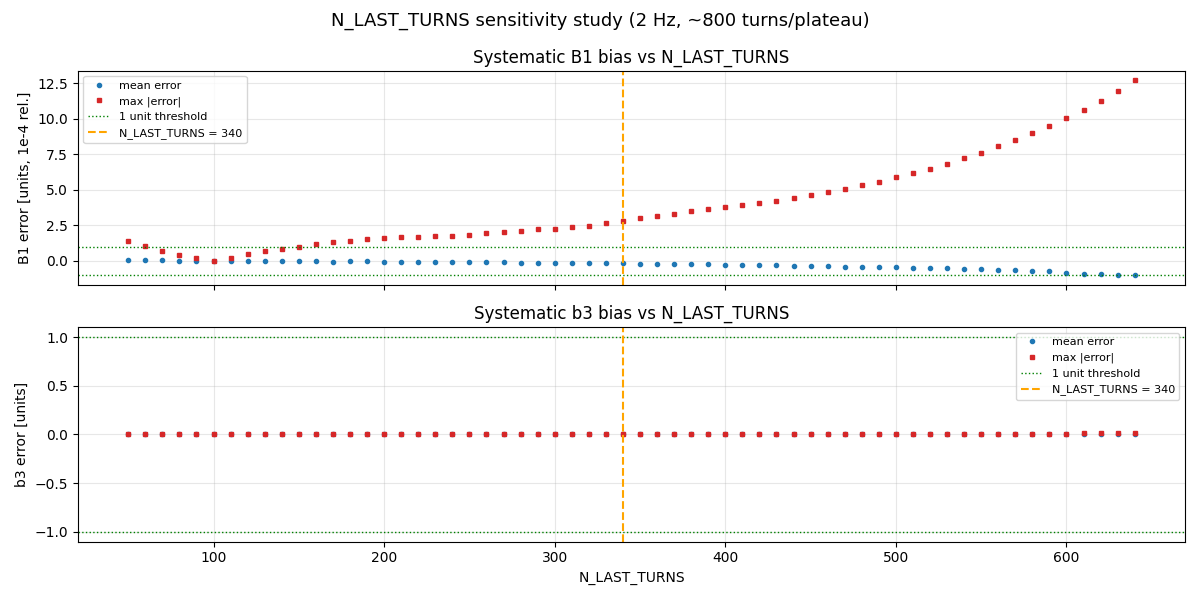


Key N_LAST_TURNS values:
  N_LAST_TURNS = 100: B1 max |error| = 0.00 units, b3 max |error| = 0.00 units
  N_LAST_TURNS = 200: B1 max |error| = 1.60 units, b3 max |error| = 0.00 units
  N_LAST_TURNS = 300: B1 max |error| = 2.25 units, b3 max |error| = 0.00 units
  N_LAST_TURNS = 340: B1 max |error| = 2.83 units, b3 max |error| = 0.00 units
  N_LAST_TURNS = 400: B1 max |error| = 3.78 units, b3 max |error| = 0.00 units
  N_LAST_TURNS = 500: B1 max |error| = 5.87 units, b3 max |error| = 0.00 units
  N_LAST_TURNS = 600: B1 max |error| = 10.04 units, b3 max |error| = 0.01 units


In [12]:
n_last_values = np.arange(50, 701, 10)
study_runs_ids = [r["run_id"] for r in run_info_list
                  if abs(r["I_nom"]) >= MIN_I_FOR_FIT]

results_sweep = []

for n_last in n_last_values:
    B1_errors = []
    b3_errors = []

    for run_id in study_runs_ids:
        rdf = df[(df["run_id"] == run_id) & df["ok_main"]].sort_values("turn_in_run")
        if len(rdf) < n_last + N_SETTLED:
            continue

        B1_ref = rdf["B1_T"].iloc[-N_SETTLED:].mean()
        B1_sel = rdf["B1_T"].iloc[-n_last:].mean()

        if abs(B1_ref) > 1e-10:
            B1_errors.append(1e4 * (B1_sel - B1_ref) / abs(B1_ref))

        if "b3_units" in rdf.columns:
            b3_ref = rdf["b3_units"].iloc[-N_SETTLED:].mean()
            b3_sel = rdf["b3_units"].iloc[-n_last:].mean()
            b3_errors.append(b3_sel - b3_ref)

    results_sweep.append({
        "n_last": n_last,
        "B1_mean_error": np.mean(B1_errors) if B1_errors else np.nan,
        "B1_max_error": np.max(np.abs(B1_errors)) if B1_errors else np.nan,
        "b3_mean_error": np.mean(b3_errors) if b3_errors else np.nan,
        "b3_max_error": np.max(np.abs(b3_errors)) if b3_errors else np.nan,
    })

df_sweep = pd.DataFrame(results_sweep)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax = axes[0]
ax.plot(df_sweep["n_last"], df_sweep["B1_mean_error"], "o", ms=3,
        color="tab:blue", label="mean error")
ax.plot(df_sweep["n_last"], df_sweep["B1_max_error"], "s", ms=3,
        color="tab:red", label="max |error|")
ax.axhline(1, color="green", ls=":", lw=1, label="1 unit threshold")
ax.axhline(-1, color="green", ls=":", lw=1)
ax.axvline(340, color="orange", ls="--", lw=1.5, label="N_LAST_TURNS = 340")
ax.set_ylabel("B1 error [units, 1e-4 rel.]")
ax.set_title("Systematic B1 bias vs N_LAST_TURNS")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(df_sweep["n_last"], df_sweep["b3_mean_error"], "o", ms=3,
        color="tab:blue", label="mean error")
ax.plot(df_sweep["n_last"], df_sweep["b3_max_error"], "s", ms=3,
        color="tab:red", label="max |error|")
ax.axhline(1, color="green", ls=":", lw=1, label="1 unit threshold")
ax.axhline(-1, color="green", ls=":", lw=1)
ax.axvline(340, color="orange", ls="--", lw=1.5, label="N_LAST_TURNS = 340")
ax.set_xlabel("N_LAST_TURNS")
ax.set_ylabel("b3 error [units]")
ax.set_title("Systematic b3 bias vs N_LAST_TURNS")
ax.legend(fontsize=8)

fig.suptitle("N_LAST_TURNS sensitivity study (2 Hz, ~800 turns/plateau)", fontsize=13)
fig.tight_layout()
plt.show()

# Key values
print("\nKey N_LAST_TURNS values:")
for n_check in [100, 200, 300, 340, 400, 500, 600]:
    row = df_sweep[df_sweep["n_last"] == n_check]
    if not row.empty:
        r = row.iloc[0]
        print(f"  N_LAST_TURNS = {n_check:3d}: "
              f"B1 max |error| = {r['B1_max_error']:.2f} units, "
              f"b3 max |error| = {r['b3_max_error']:.2f} units")

## 11. Precycle Region — Turn-by-Turn Current & Field

The precycles provide a view of the magnetic conditioning before the staircase.
Process a subset of the precycle turns for visualization.

Processing 14150 precycle plateau turns...


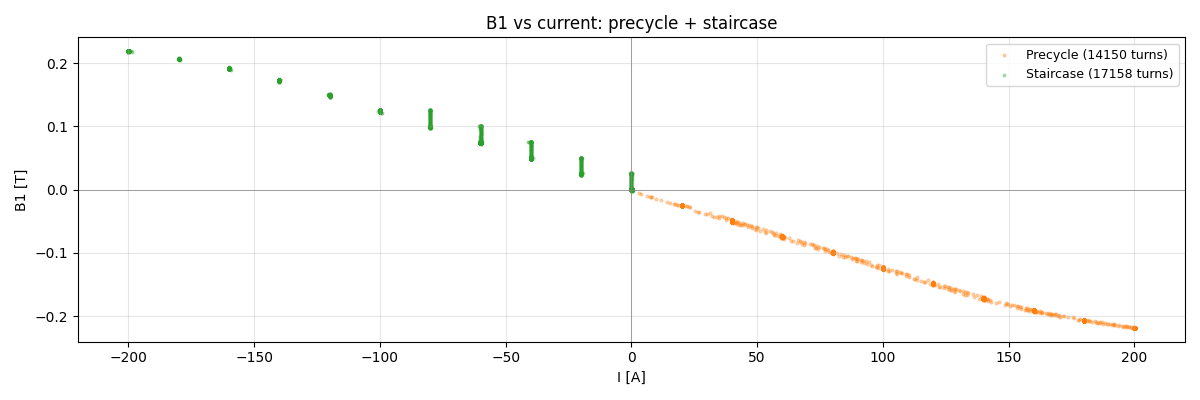

Precycle: 14150 turns, 14150 ok


In [13]:
# Process precycle turns (all plateau turns before staircase)
pre_plateau_mask = is_plateau & (np.arange(n_turns) < staircase_start_turn)
pre_idx = np.where(pre_plateau_mask)[0]

if len(pre_idx) > 0:
    print(f"Processing {len(pre_idx)} precycle plateau turns...")
    result_pre, C_pre, C_units_pre, ok_pre = process_kn_pipeline(
        flux_abs_turns=flux_abs[pre_idx],
        flux_cmp_turns=flux_cmp[pre_idx],
        t_turns=t_all[pre_idx],
        I_turns=I_all[pre_idx],
        kn=kn_integral,
        r_ref=R_REF,
        magnet_order=MAGNET_ORDER,
        options=OPTIONS,
        drift_mode=DRIFT_MODE,
        min_b1_T=MIN_B1_T,
        flip_signal_polarity=FLIP_SIGNAL_POLARITY,
        encoder_offset_rad=ENCODER_OFFSET_RAD,
    )

    extra_pre = [{"global_turn": int(t)} for t in pre_idx]
    rows_pre = build_harmonic_rows(result_pre, C_pre, C_units_pre, ok_pre,
                                    MAGNET_ORDER, extra_pre)
    df_pre = pd.DataFrame(rows_pre)

    # Plot precycle + staircase B1 vs current
    fig, ax = plt.subplots(figsize=(12, 4))

    # Precycle
    ok_pre_mask = df_pre["ok_main"].values
    ax.scatter(df_pre.loc[ok_pre_mask, "I_mean_A"],
              df_pre.loc[ok_pre_mask, "B1_T"],
              s=4, alpha=0.3, color="tab:orange", label=f"Precycle ({ok_pre_mask.sum()} turns)")

    # Staircase
    ok_stair = df["ok_main"].values
    ax.scatter(df.loc[ok_stair, "I_mean_A"],
              df.loc[ok_stair, "B1_T"],
              s=4, alpha=0.3, color="tab:green", label=f"Staircase ({ok_stair.sum()} turns)")

    ax.set_xlabel("I [A]")
    ax.set_ylabel("B1 [T]")
    ax.set_title("B1 vs current: precycle + staircase")
    ax.legend(fontsize=9)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    fig.tight_layout()
    plt.show()

    print(f"Precycle: {len(df_pre)} turns, {ok_pre_mask.sum()} ok")
else:
    print("No precycle plateau turns found.")

## 12. Summary & Recommendations

In [14]:
print("=" * 80)
print("  Eddy Current Settling -- Summary (GOOD fits, R² >= 0.9)")
print(f"  MC62 staircase_2Hz_morning, 2 Hz rotation, 1 A/s ramp rate")
print("=" * 80)

if len(df_fits) > 0:
    print(f"\n  Good fits: {len(df_fits)} / {len(df_fits_all)} plateaus")
    print(f"  Tau range: {df_fits['tau_s'].min():.1f} - {df_fits['tau_s'].max():.1f} s")
    print(f"  Tau mean:  {df_fits['tau_s'].mean():.1f} \u00b1 {df_fits['tau_s'].std():.1f} s")

    # 5*tau settling rule
    tau_max_s = df_fits["tau_s"].max()
    settle_5tau_s = 5 * tau_max_s
    settle_5tau_turns = settle_5tau_s / T_PER_TURN
    print(f"\n  5\u00d7\u03c4_max = {settle_5tau_s:.0f} s = {settle_5tau_turns:.0f} turns (at 2 Hz)")
    print(f"  With ~{int(run_info_list[1]['n_turns'])} turns/plateau, safe N_LAST_TURNS = "
          f"{int(run_info_list[1]['n_turns']) - int(settle_5tau_turns)}")

    print(f"\n  Note: Previous 02_staircase_without_shims (1 Hz, 350 turns/plateau)")
    print(f"  used N_LAST_TURNS=170. At 2 Hz with ~800 turns/plateau,")
    print(f"  N_LAST_TURNS=340 gives equivalent settling time.")

print(f"\n{'Run':>4s} {'I [A]':>8s} {'Branch':>10s} "
      f"{'\u03c4 [s]':>8s} {'A [\u00b5T]':>10s} {'B1_inf [T]':>12s} {'R\u00b2':>8s} {'Quality':>12s}")
print("-" * 82)
for _, r in df_fits_all.iterrows():
    tau_s = r["tau"] * T_PER_TURN
    print(f"{r['run_id']:4.0f} {r['I_nom']:+8.1f} {r['branch']:>10s} "
          f"{tau_s:8.1f} {r['A']*1e6:+10.1f} {r['B_inf']:+12.6f} "
          f"{r['r2']:8.4f} {r['quality']:>12s}")

  Eddy Current Settling -- Summary (GOOD fits, R² >= 0.9)
  MC62 staircase_2Hz_morning, 2 Hz rotation, 1 A/s ramp rate

  Good fits: 6 / 19 plateaus
  Tau range: 21.4 - 28.5 s
  Tau mean:  25.7 ± 2.7 s

  5×τ_max = 143 s = 285 turns (at 2 Hz)
  With ~744 turns/plateau, safe N_LAST_TURNS = 459

  Note: Previous 02_staircase_without_shims (1 Hz, 350 turns/plateau)
  used N_LAST_TURNS=170. At 2 Hz with ~800 turns/plateau,
  N_LAST_TURNS=340 gives equivalent settling time.

 Run    I [A]     Branch    τ [s]     A [µT]   B1_inf [T]       R²      Quality
----------------------------------------------------------------------------------
   1    -20.0 descending     26.7     -812.0    +0.024549   0.9610         GOOD
   2    -40.0 descending     27.0     -954.7    +0.049509   0.9527         GOOD
   3    -60.0 descending     28.5    -1051.0    +0.074449   0.9415         GOOD
   4    -80.0 descending     27.0    -1240.8    +0.099349   0.9271         GOOD
   5   -100.0 descending     23.7    -1528

## Double-Exponential Fit Comparison

### Model

A double-exponential model captures two distinct eddy-current decay time scales:

$$
B_1(t) = B_\infty + A_1 \, e^{-t/\tau_1} + A_2 \, e^{-t/\tau_2}
$$

where $\tau_1 < \tau_2$ by convention. Physically:
- **Fast component** ($\tau_1$): eddy currents in thin iron laminations (short diffusion path, $d$ small)
- **Slow component** ($\tau_2$): eddy currents in thicker structural elements (yoke, end plates, $d$ large)

### Fit procedure

Initial guesses are seeded from the single-exponential results:
- $A_1^{(0)} = A_2^{(0)} = A_{\rm single}/2$ (amplitude split 50/50)
- $\tau_1^{(0)} = \tau_{\rm single}/3$ (fast), $\tau_2^{(0)} = 2\,\tau_{\rm single}$ (slow)
- Bounds: $\tau_1 \in [0.5, 1000]$, $\tau_2 \in [0.5, 4000]$ turns
- If the fit converges with $\tau_1 > \tau_2$, the components are swapped to enforce the convention

### Comparison criterion

The improvement is measured by $\Delta R^2 = R^2_{\rm double} - R^2_{\rm single}$. If $\Delta R^2 \ll 0.01$, the single-exponential is adequate and the extra 2 parameters are not justified (Occam's razor).


Double-exponential fit comparison:
 Run    I [A]     Branch  R²_1exp  R²_2exp      ΔR²   τ1 [s]   τ2 [s]
------------------------------------------------------------------------------
   1    -20.0 descending   0.9610   0.9895  +0.0284      4.1     43.5
   2    -40.0 descending   0.9527   0.9860  +0.0332      4.1     43.3
   3    -60.0 descending   0.9415   0.9794  +0.0379      4.1     45.8
   4    -80.0 descending   0.9271   0.9719  +0.0448      3.4     44.3
   5   -100.0 descending   0.9237   0.9674  +0.0437      2.3     35.5
   6   -120.0 descending   0.9231   0.9583  +0.0352      3.6     34.5
   7   -140.0 descending   0.8582   0.9035  +0.0453      3.8     27.2
   8   -160.0 descending   0.6414   0.7284  +0.0870      1.4     10.3
   9   -180.0 descending   0.3040   0.4231  +0.1191      1.3     15.2
  10   -200.0 descending   0.1505   0.1529  +0.0024      3.0     22.3
  11   -180.0  ascending   0.0231   0.0245  +0.0014      0.6      3.8
  12   -160.0  ascending   0.1531   0.1650  +0

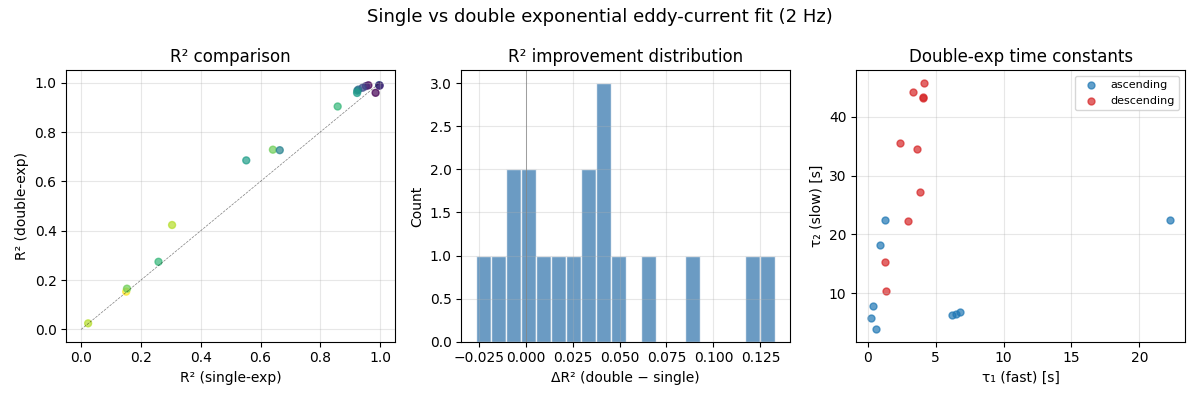


Runs where double-exp improved R² by >0.05: 4 / 19
Mean ΔR²: 0.0341
Max ΔR²:  0.1328


In [15]:
from rotating_coil_analyzer.analysis.utility_functions import double_eddy_model

dbl_records = []

for _, srow in df_fits_all.iterrows():
    run_id = int(srow["run_id"])
    rdf = df[(df["run_id"] == run_id) & df["ok_main"]].sort_values("turn_in_run")
    if rdf.empty:
        continue

    turns = rdf["turn_in_run"].values.astype(float)
    B1 = rdf["B1_T"].values

    # Single-exp R²
    r2_single = srow["r2"]

    # Double-exp initial guesses from single-exp results (in turns)
    B_inf_0 = srow["B_inf"]
    A_total = srow["A"]
    tau_single_turns = srow["tau"]

    if not np.isfinite(tau_single_turns):
        continue

    p0 = [B_inf_0, A_total * 0.5, tau_single_turns / 3,
           A_total * 0.5, tau_single_turns * 2]
    bounds_lo = [-np.inf, -np.inf, 0.5, -np.inf, 0.5]
    bounds_hi = [np.inf, np.inf, 1000, np.inf, 4000]

    try:
        popt, pcov = curve_fit(
            double_eddy_model, turns, B1, p0=p0,
            bounds=(bounds_lo, bounds_hi), maxfev=20000,
        )
        B_inf, A1, tau1, A2, tau2 = popt

        # Enforce tau1 < tau2
        if tau1 > tau2:
            A1, A2 = A2, A1
            tau1, tau2 = tau2, tau1

        B1_pred = double_eddy_model(turns, *popt)
        ss_res = np.sum((B1 - B1_pred) ** 2)
        ss_tot = np.sum((B1 - B1.mean()) ** 2)
        r2_double = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

        dbl_records.append({
            "run_id": run_id,
            "I_nom": srow["I_nom"],
            "branch": srow["branch"],
            "r2_single": r2_single,
            "r2_double": r2_double,
            "delta_r2": r2_double - r2_single,
            "tau1_turns": tau1,
            "tau2_turns": tau2,
            "tau1_s": tau1 * T_PER_TURN,
            "tau2_s": tau2 * T_PER_TURN,
            "A1": A1,
            "A2": A2,
            "B_inf": B_inf,
        })
    except (RuntimeError, ValueError) as e:
        dbl_records.append({
            "run_id": run_id,
            "I_nom": srow["I_nom"],
            "branch": srow["branch"],
            "r2_single": r2_single,
            "r2_double": np.nan,
            "delta_r2": np.nan,
            "tau1_turns": np.nan,
            "tau2_turns": np.nan,
            "tau1_s": np.nan,
            "tau2_s": np.nan,
            "A1": np.nan,
            "A2": np.nan,
            "B_inf": np.nan,
        })

df_dbl = pd.DataFrame(dbl_records)

# ── Comparison table ──
print("Double-exponential fit comparison:")
print(f"{'Run':>4s} {'I [A]':>8s} {'Branch':>10s} "
      f"{'R²_1exp':>8s} {'R²_2exp':>8s} {'ΔR²':>8s} "
      f"{'τ1 [s]':>8s} {'τ2 [s]':>8s}")
print("-" * 78)
for _, r in df_dbl.iterrows():
    r2d = f"{r['r2_double']:.4f}" if pd.notna(r['r2_double']) else "FAIL"
    dr = f"{r['delta_r2']:+.4f}" if pd.notna(r['delta_r2']) else "---"
    t1 = f"{r['tau1_s']:.1f}" if pd.notna(r['tau1_s']) else "---"
    t2 = f"{r['tau2_s']:.1f}" if pd.notna(r['tau2_s']) else "---"
    print(f"{r['run_id']:4.0f} {r['I_nom']:+8.1f} {r['branch']:>10s} "
          f"{r['r2_single']:8.4f} {r2d:>8s} {dr:>8s} "
          f"{t1:>8s} {t2:>8s}")

# ── Plots ──
valid = df_dbl.dropna(subset=["r2_double"])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# (a) R² scatter
ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", lw=0.5, alpha=0.5)
ax.scatter(valid["r2_single"], valid["r2_double"], s=25, alpha=0.7,
           c=valid["I_nom"].abs(), cmap="viridis")
ax.set_xlabel("R² (single-exp)")
ax.set_ylabel("R² (double-exp)")
ax.set_title("R² comparison")

# (b) ΔR² histogram
ax = axes[1]
ax.hist(valid["delta_r2"], bins=20, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("ΔR² (double − single)")
ax.set_ylabel("Count")
ax.set_title("R² improvement distribution")

# (c) tau1 vs tau2 (in seconds)
ax = axes[2]
for br, col in [("ascending", "tab:blue"), ("descending", "tab:red")]:
    mask = valid["branch"] == br
    if mask.any():
        ax.scatter(valid.loc[mask, "tau1_s"], valid.loc[mask, "tau2_s"],
                   s=25, alpha=0.7, color=col, label=br)
ax.set_xlabel("τ₁ (fast) [s]")
ax.set_ylabel("τ₂ (slow) [s]")
ax.set_title("Double-exp time constants")
ax.legend(fontsize=8)

fig.suptitle("Single vs double exponential eddy-current fit (2 Hz)", fontsize=13)
fig.tight_layout()
plt.show()

# ── Summary ──
n_improved = (valid["delta_r2"] > 0.05).sum()
print(f"\nRuns where double-exp improved R² by >0.05: {n_improved} / {len(valid)}")
if len(valid) > 0:
    print(f"Mean ΔR²: {valid['delta_r2'].mean():.4f}")
    print(f"Max ΔR²:  {valid['delta_r2'].max():.4f}")